# World Cup 2026 — Match Outcome Predictor

A deliberately **simple** machine-learning project: given two national teams,
predict whether the match ends in a **home win / draw / away win**.

**Stack:** Python + pandas + scikit-learn, all in this one notebook.
**Data:** historical international match results (`data/results.csv`).
**Model:** a `RandomForestClassifier` on three small, leak-free features.

The goal is a working `predict("Brazil", "Croatia")` function plus an honest
read on accuracy — not a perfect model. (3-class football prediction tops out
around ~50-55% because draws are genuinely hard to call.)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, deque
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

DATA_PATH   = "data/results.csv"
START_YEAR  = 2000   # use only the modern era
FORM_WINDOW = 5      # how many recent matches define a team's "form"
pd.set_option("display.max_columns", None)

> **Why is `draw` recall ~0?** Draws are the minority class and the hardest to call, so a draw is almost never the single *most likely* outcome — the model therefore rarely picks it as its top prediction. But it still assigns draws a realistic **20-30% probability** (see the `predict()` output below). Beating the baselines on overall accuracy is the win here; nailing draws is a known hard problem in football modelling. Try `class_weight="balanced"` on the model if you want it to predict draws more often (usually at a small cost to accuracy).

## 1. Load & clean the data

Each row is one international match. Future/unplayed fixtures (including the
2026 World Cup) have missing scores — we set those aside and train only on
matches that have actually been played, from `START_YEAR` onward.

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

# keep only matches that have been played (real scores)
played = df.dropna(subset=["home_score", "away_score"]).copy()
played["home_score"] = played["home_score"].astype(int)
played["away_score"] = played["away_score"].astype(int)

# normalise the neutral-venue flag to a real boolean
played["neutral"] = played["neutral"].astype(str).str.upper().eq("TRUE")

# modern era only, sorted in time order (critical for leak-free features)
played = (played[played["date"].dt.year >= START_YEAR]
          .sort_values("date")
          .reset_index(drop=True))

print(f"{len(played):,} played matches, "
      f"{played['date'].dt.year.min()}-{played['date'].dt.year.max()}")
played.head()

25,397 played matches, 2000-2026


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,2000-01-04,Egypt,Togo,2,1,Friendly,Aswan,Egypt,False
1,2000-01-07,Tunisia,Togo,7,0,Friendly,Tunis,Tunisia,False
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,Port of Spain,Trinidad and Tobago,False
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,Ouagadougou,Burkina Faso,False
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,Los Angeles,United States,True


## 2. Define what we predict (the label)

Compare the two scores to label every match as `home_win`, `draw`, or
`away_win`. The class balance below is our reality check: draws are the
minority, which is exactly why they're hard to predict.

In [4]:
played["result"] = np.select(
    [played.home_score > played.away_score,
     played.home_score < played.away_score],
    ["home_win", "away_win"],
    default="draw",
)
played["result"].value_counts(normalize=True).round(3)

result
home_win    0.482
away_win    0.285
draw        0.233
Name: proportion, dtype: float64

## 3. Feature engineering (kept deliberately small)

We use just **three** features, all computed using only information available
*before* each match (no peeking at the result):

1. **`elo_diff`** — difference in Elo rating. Every team starts at 1500; after
   each match the winner gains points and the loser loses them, scaled by how
   surprising the result was. This single number is the strongest signal.
2. **`form_diff`** — difference in recent form (average goal difference over
   each team's last few matches).
3. **`neutral`** — whether the match is on neutral ground (most World Cup games
   are, except for host nations), which controls for home advantage.

### 3a. Elo ratings

In [5]:
K        = 30   # how fast ratings move after each match
HOME_ADV = 60   # Elo points granted to the home side on non-neutral pitches

def expected_score(r_a, r_b):
    return 1.0 / (1.0 + 10 ** ((r_b - r_a) / 400))

ratings = {}              # team -> current Elo (updated as we sweep forward)
home_elo, away_elo = [], []

for row in played.itertuples(index=False):
    ra = ratings.get(row.home_team, 1500.0)
    rb = ratings.get(row.away_team, 1500.0)
    home_elo.append(ra)   # record the PRE-match ratings (no leakage)
    away_elo.append(rb)

    adv = 0 if row.neutral else HOME_ADV          # home edge only off-neutral
    exp_home = expected_score(ra + adv, rb)

    if   row.home_score > row.away_score: s_home = 1.0
    elif row.home_score < row.away_score: s_home = 0.0
    else:                                 s_home = 0.5

    ratings[row.home_team] = ra + K * (s_home - exp_home)
    ratings[row.away_team] = rb - K * (s_home - exp_home)

played["home_elo"] = home_elo
played["away_elo"] = away_elo
played["elo_diff"] = played["home_elo"] - played["away_elo"]
played[["home_team", "away_team", "home_elo", "away_elo", "elo_diff"]].tail()

,home_team,away_team,home_elo,away_elo,elo_diff
25392,Canada,Switzerland,1780.642472,1796.008458,-15.365987
25393,Scotland,Brazil,1694.994110,1927.295125,-232.301015
25394,Mexico,Czech Republic,1862.649966,1693.112662,169.537303
25395,South Africa,South Korea,1620.259103,1797.468631,-177.209529
25396,Morocco,Haiti,1889.010135,1606.029943,282.980191


### 3b. Recent form

Average goal difference over each team's last `FORM_WINDOW` matches, again
recorded *before* the current match so there is no leakage.

In [ ]:
recent = defaultdict(lambda: deque(maxlen=FORM_WINDOW))
home_form, away_form = [], []

for row in played.itertuples(index=False):
    hf = np.mean(recent[row.home_team]) if recent[row.home_team] else 0.0
    af = np.mean(recent[row.away_team]) if recent[row.away_team] else 0.0
    home_form.append(hf)
    away_form.append(af)

    gd = row.home_score - row.away_score
    recent[row.home_team].append(gd)    # from the home team's perspective
    recent[row.away_team].append(-gd)   # from the away team's perspective

played["home_form"] = home_form
played["away_form"] = away_form
played["form_diff"] = played["home_form"] - played["away_form"]

## 4. Train / test split — by date

We train on the **oldest 80%** of matches and test on the **most recent 20%**.
Splitting by time (instead of randomly) mimics the real task: using the past to
predict the future.

In [ ]:
FEATURES = ["elo_diff", "form_diff", "neutral"]
X = played[FEATURES].astype(float)
y = played["result"]

split = int(len(played) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"train: {len(X_train):,} matches (up to {played['date'].iloc[split-1].date()})")
print(f"test:  {len(X_test):,} matches (from {played['date'].iloc[split].date()})")

train: 20,317 matches (up to 2021-09-05)
test:  5,080 matches (from 2021-09-05)


## 5. Train the model

A `RandomForestClassifier` with light regularisation (shallow trees, a minimum
leaf size) so it generalises instead of memorising. No tuning needed for v1.

In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

## 6. Evaluate — honestly, against baselines

Raw accuracy is meaningless without something to beat. We compare against two
naive baselines:

- **Always predict home win** — the single most common class.
- **Pick the higher-Elo team** — a no-machine-learning heuristic.

**Success = beating both.** The confusion matrix then shows *where* the model
is right and wrong (spoiler: draws are the hard part).

In [ ]:
pred = model.predict(X_test)
acc       = accuracy_score(y_test, pred)
base_home = accuracy_score(y_test, ["home_win"] * len(y_test))
elo_pick  = np.where(X_test["elo_diff"] >= 0, "home_win", "away_win")
base_elo  = accuracy_score(y_test, elo_pick)

print(f"Model accuracy:           {acc:.3f}")
print(f"Baseline (always home):   {base_home:.3f}")
print(f"Baseline (higher Elo):    {base_elo:.3f}")
print(f"\nBeats both baselines? {'YES' if acc > max(base_home, base_elo) else 'NO'}\n")
print(classification_report(y_test, pred, zero_division=0))

Model accuracy:           0.600
Baseline (always home):   0.476
Baseline (higher Elo):    0.596

Beats both baselines? YES

              precision    recall  f1-score   support

    away_win       0.56      0.64      0.60      1500
        draw       0.00      0.00      0.00      1160
    home_win       0.62      0.86      0.72      2420

    accuracy                           0.60      5080
   macro avg       0.39      0.50      0.44      5080
weighted avg       0.46      0.60      0.52      5080



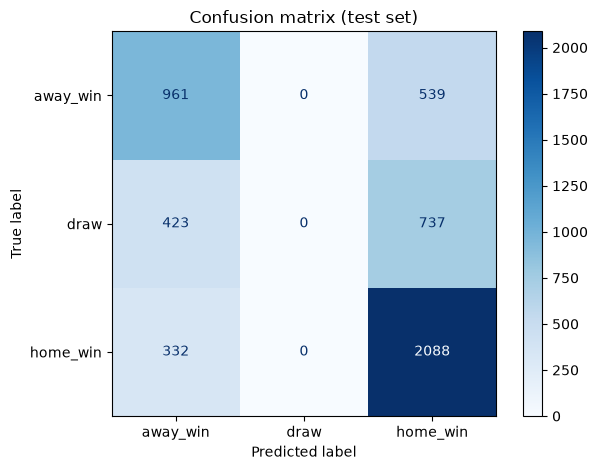

In [ ]:
cm = confusion_matrix(y_test, pred, labels=model.classes_)
ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot(cmap="Blues")
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

## 7. Predict any match

`predict(team_a, team_b, neutral=True)` looks up each team's current Elo and
form, then returns the three outcome probabilities. `team_a` is treated as the
home side; set `neutral=False` if `team_a` is actually playing at home.

In [ ]:
# snapshot each team's final form after the most recent match
latest_form = {t: (np.mean(v) if v else 0.0) for t, v in recent.items()}

def predict(team_a, team_b, neutral=True):
    for t in (team_a, team_b):
        if t not in ratings:
            raise ValueError(f"Unknown team: {t!r} "
                             f"(check spelling, e.g. 'United States', 'South Korea').")

    elo_diff  = ratings[team_a] - ratings[team_b]
    form_diff = latest_form.get(team_a, 0.0) - latest_form.get(team_b, 0.0)
    row = pd.DataFrame([[elo_diff, form_diff, float(neutral)]], columns=FEATURES)

    p = dict(zip(model.classes_, model.predict_proba(row)[0]))
    venue = "neutral venue" if neutral else f"{team_a} at home"
    print(f"{team_a} vs {team_b}  ({venue})")
    print(f"  {team_a} win : {p['home_win']:.0%}")
    print(f"  Draw        : {p['draw']:.0%}")
    print(f"  {team_b} win : {p['away_win']:.0%}")
    return p

_ = predict("Brazil", "Croatia")
print()
_ = predict("United States", "Wales", neutral=False)

Brazil vs Croatia  (neutral venue)
  Brazil win : 65%
  Draw        : 25%
  Croatia win : 11%

United States vs Wales  (United States at home)
  United States win : 69%
  Draw        : 21%
  Wales win : 10%


## 8. (Optional) Predict the 2026 World Cup fixtures

The dataset already contains the scheduled 2026 World Cup matches (with blank
scores). Let's run the predictor over them. Host nations (USA / Canada /
Mexico) play at home; everyone else is on neutral ground.

In [ ]:
fixtures = df[(df["tournament"] == "FIFA World Cup")
              & (df["home_score"].isna())
              & (df["date"].dt.year == 2026)].copy()

HOSTS = {"United States", "Canada", "Mexico"}
rows = []
for f in fixtures.itertuples(index=False):
    if f.home_team not in ratings or f.away_team not in ratings:
        continue
    neutral   = f.home_team not in HOSTS
    elo_diff  = ratings[f.home_team] - ratings[f.away_team]
    form_diff = latest_form.get(f.home_team, 0.0) - latest_form.get(f.away_team, 0.0)
    r = pd.DataFrame([[elo_diff, form_diff, float(neutral)]], columns=FEATURES)
    p = dict(zip(model.classes_, model.predict_proba(r)[0]))
    label = {"home_win": f.home_team, "away_win": f.away_team, "draw": "Draw"}
    rows.append({
        "date": f.date.date(),
        "home": f.home_team, "away": f.away_team,
        "home_win": f"{p['home_win']:.0%}",
        "draw": f"{p['draw']:.0%}",
        "away_win": f"{p['away_win']:.0%}",
        "predicted": label[max(p, key=p.get)],
    })

print(f"{len(rows)} fixtures predicted\n")
pd.DataFrame(rows).head(25)

18 fixtures predicted



,date,home,away,home_win,draw,away_win,predicted
0,2026-06-25,United States,Turkey,49%,27%,25%,United States
1,2026-06-25,Paraguay,Australia,37%,24%,39%,Australia
2,2026-06-25,Curaçao,Ivory Coast,13%,14%,74%,Ivory Coast
3,2026-06-25,Ecuador,Germany,20%,29%,52%,Germany
4,2026-06-25,Japan,Sweden,75%,16%,9%,Japan
5,2026-06-25,Tunisia,Netherlands,7%,7%,85%,Netherlands
6,2026-06-26,Egypt,Iran,22%,26%,51%,Iran
7,2026-06-26,New Zealand,Belgium,11%,16%,73%,Belgium
8,2026-06-26,Cape Verde,Saudi Arabia,36%,27%,37%,Saudi Arabia
9,2026-06-26,Uruguay,Spain,11%,25%,64%,Spain
